# Análise Exploratória de Dados (EDA)

Notebook para exploração e análise dos dados de churn.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [2]:
# Carregar dados
df = pd.read_csv('../../src/data/churn.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Informações gerais
df.info()
print('\nEstatísticas:')
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


---
## EDA — Análise Exploratória

In [4]:
# Visão geral do dataset
print('=== Informações do dataset ===')
print(df.info())
print('\n=== Estatísticas descritivas ===')
df.describe()

=== Informações do dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBi

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Converte Churn para numérico se ainda não foi feito
if df['Churn'].dtype == object:
    df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
    print("Churn convertido!")

# Garante que TotalCharges é numérico também (vem como string no dataset original)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(0, inplace=True)

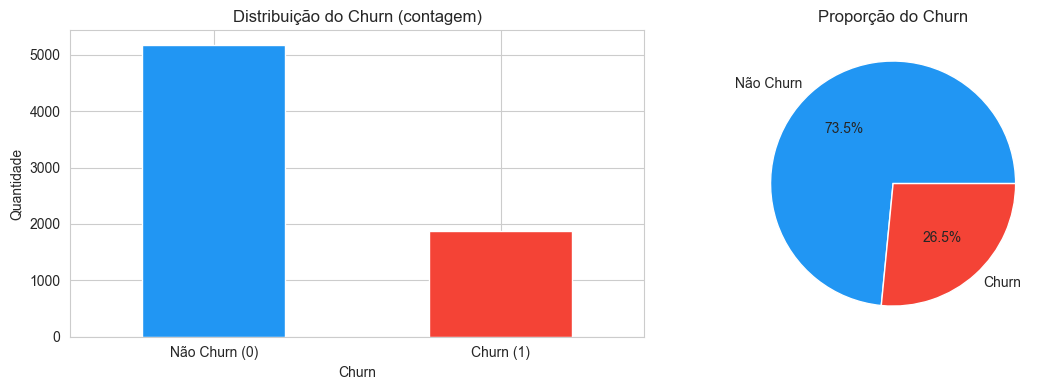

In [8]:
# Distribuição do alvo (Churn)
# Dataset desbalanceado: ~26% churn vs ~74% não-churn
# Isso impacta a escolha das métricas:F1 e ROC-AUC são mais indicadas que accuracy

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Gráfico de contagem
df['Churn'].value_counts().plot(kind='bar', ax=axes[0], color=['#2196F3', '#F44336'])
axes[0].set_title('Distribuição do Churn (contagem)')
axes[0].set_xticklabels(['Não Churn (0)', 'Churn (1)'], rotation=0)
axes[0].set_ylabel('Quantidade')

# Gráfico de pizza
df['Churn'].value_counts().plot(kind='pie', ax=axes[1],
    labels=['Não Churn', 'Churn'],
    autopct='%1.1f%%',
    colors=['#2196F3', '#F44336'])
axes[1].set_title('Proporção do Churn')
axes[1].set_ylabel('')

from pathlib import Path
out_dir = Path.home() / "Tech-challenge-step-1" / "Tech-challenge-step-1" / "src" / "data"
out_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(out_dir / 'eda_churn_distribuicao.png', dpi=100, bbox_inches='tight')
plt.show()

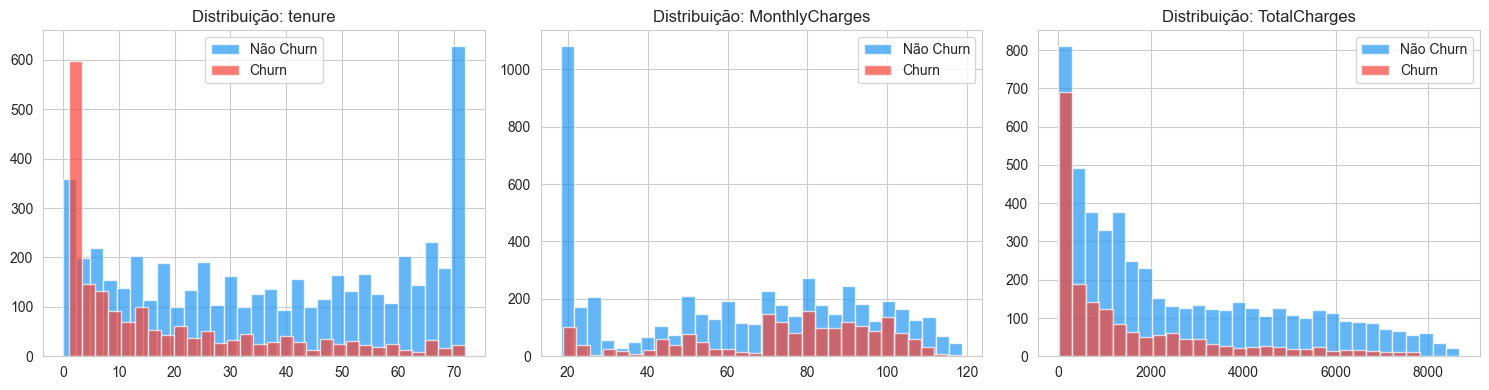

In [9]:
# Célula 8 — Variáveis numéricas vs Churn
# tenure = tempo como cliente | MonthlyCharges = cobranças mensais

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(num_cols):
    df[df['Churn'] == 0][col].hist(ax=axes[i], alpha=0.7, label='Não Churn', color='#2196F3', bins=30)
    df[df['Churn'] == 1][col].hist(ax=axes[i], alpha=0.7, label='Churn', color='#F44336', bins=30)
    axes[i].set_title(f'Distribuição: {col}')
    axes[i].legend()

from pathlib import Path
out_dir = Path.home() / "Tech-challenge-step-1" / "Tech-challenge-step-1" / "src" / "data"
out_dir.mkdir(parents=True, exist_ok=True)

plt.tight_layout()
plt.savefig(out_dir / 'eda_numericas.png', dpi=100, bbox_inches='tight')
plt.show()